<a href="https://colab.research.google.com/github/ChristianParsons98/PG_Lab_Code/blob/main/Sample_5_Comp_Na3PS4_Raman_Plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install lmfit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.7/97.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 8.1 MB/s eta 0:00:00


In [2]:
!pip install pybaselines

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.9/211.9 kB 5.4 MB/s eta 0:00:00


In [3]:
%matplotlib inline
from sympy import init_printing
init_printing(use_latex=True)
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import sympy as sp
import pandas as pd
import math
import scipy
from scipy.stats import chisquare
print(scipy.__version__)
from scipy.optimize import leastsq
from scipy.special import voigt_profile
from sklearn.metrics import r2_score
import csv
from scipy.signal import find_peaks
import lmfit
from lmfit.models import VoigtModel, LinearModel, GaussianModel, LorentzianModel

from pybaselines import Baseline

# This document is used to Find the Center and FWHM of Raman Peaks
# Uses the file 'Sample.PRN' to plot Raman Peaks

#This document attempts a rewrite of the code to find Raman Peaks.


1.16.3


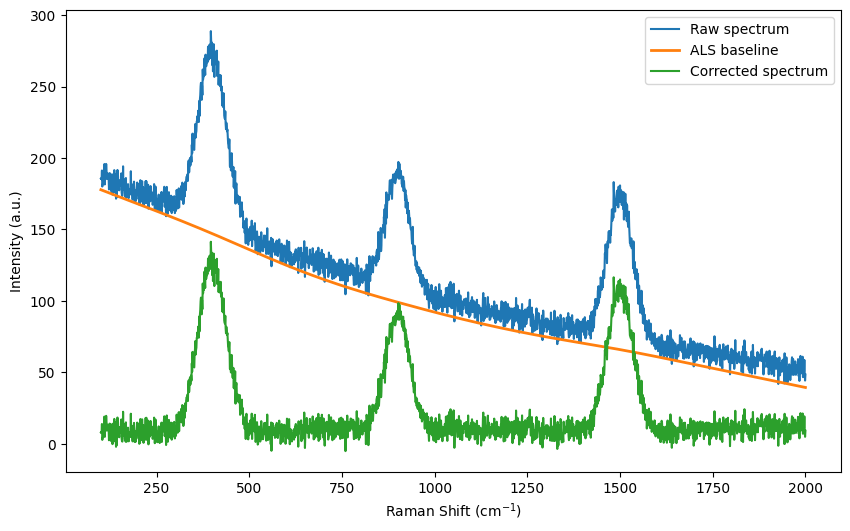

In [4]:
#Quick test of Asymetric Leaast Squared Background subtraction

#Let's make up some fake data to test things.
shift = np.linspace(100, 2000, 2000)

baseline_true = 200*np.exp(-shift/1500)

peaks = (
    120*np.exp(-(shift-400)**2/3000) +
    80*np.exp(-(shift-900)**2/2000) +
    100*np.exp(-(shift-1500)**2/2500)
)

noise = np.random.normal(0,5,len(shift))

intensity = baseline_true + peaks + noise

#using pybaselines package
baseline_fitter = Baseline(x_data=shift)

#Here, lam is a smoothness param and p is an asymetry param
baseline, params = baseline_fitter.asls(intensity,lam=1e7,p=0.001,max_iter=20)

corrected = intensity - baseline

#Plotting Results
plt.figure(figsize=(10,6))

plt.plot(shift, intensity, label="Raw spectrum")
plt.plot(shift, baseline, label="ALS baseline", linewidth=2)
plt.plot(shift, corrected, label="Corrected spectrum")

plt.xlabel("Raman Shift (cm$^{-1}$)")
plt.ylabel("Intensity (a.u.)")
plt.legend()
plt.show()


In [5]:
#Importing the Results for LLTO and LLYTO

def Load_Raman_Data(file_path):
    #Function to load tab-delimited .PRN Raman data from Renishaw
    df = pd.read_csv(file_path, delimiter='\t', header=None, names=['wavenumber', 'intensity'])
    return df


#Load the file file
dfA1 = Load_Raman_Data('/content/5-2-NPS2.PRN')


#There is a strange hidden character at the end of the file, so we need to skip the last entry here.
wna1 = dfA1['wavenumber'].to_numpy()
wna1 = wna1[:-1].astype(float)
intensitya1 = dfA1['intensity'].to_numpy()[:-1]



In [6]:
df_Sim = pd.read_csv('/content/raman_06-06_0.02 1.csv', comment="#", names=["Mode", "Wavenumber (cm-1)", "Activity"])
#df_Sim


In [7]:
#Basic lorentzian Definition
def lorentzian(x, x0, A, fwhm):
    gamma = fwhm / 2
    return A * (gamma**2) / ((x - x0)**2 + gamma**2)

x = np.linspace(0, 700, 5000)  # wavenumber axis
spectrum = np.zeros_like(x)

for _, row in df_Sim.iterrows():
    spectrum += lorentzian(
        x,
        row["Wavenumber (cm-1)"],
        row["Activity"],
        10   # FWHM
    )

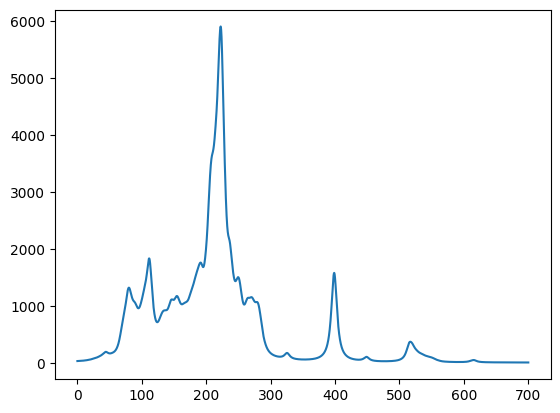

In [8]:
plt.plot(x,spectrum)
plt.show()

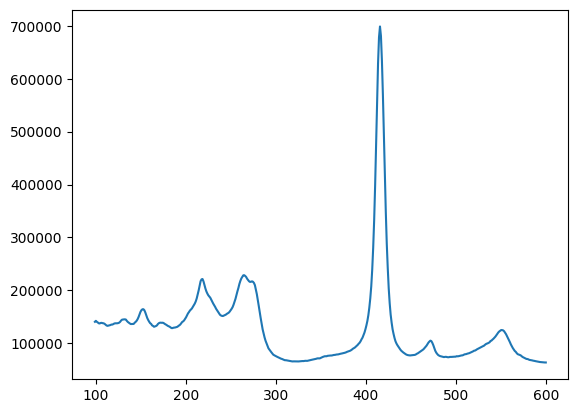

In [9]:
plt.plot(wna1,intensitya1)
plt.show()

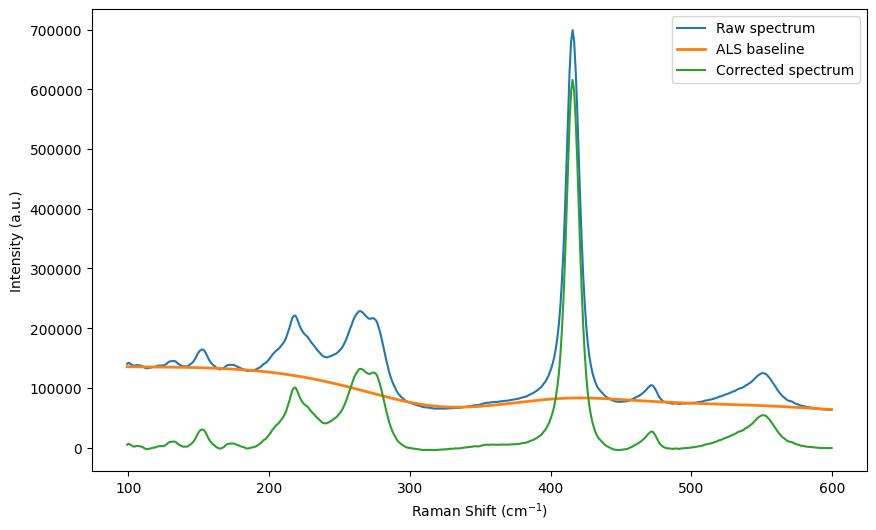

In [10]:
#using pybaselines package
baseline_fitter1 = Baseline(x_data=wna1)

#Here, lam is a smoothness param and p is an asymetry param
baseline1, params1 = baseline_fitter1.asls(intensitya1,lam=1e5,p=0.01,max_iter=20)

corrected1 = intensitya1 - baseline1

#Plotting Results
plt.figure(figsize=(10,6))

plt.plot(wna1, intensitya1, label="Raw spectrum")
plt.plot(wna1, baseline1, label="ALS baseline", linewidth=2)
plt.plot(wna1, corrected1, label="Corrected spectrum")

plt.xlabel("Raman Shift (cm$^{-1}$)")
plt.ylabel("Intensity (a.u.)")
plt.legend()
#plt.savefig('NPS_3.png',dpi=900)
plt.show()

In [11]:
#Adding the Simulated Raman Spectrum
#Basic lorentzian Definition
def lorentzian(x, x0, A, fwhm):
    gamma = fwhm / 2
    return A * (gamma**2) / ((x - x0)**2 + gamma**2)

x = np.linspace(0, 700, 5000)  # wavenumber axis
spectrum = np.zeros_like(x)

for _, row in df_Sim.iterrows():
    spectrum += lorentzian(
        x,
        row["Wavenumber (cm-1)"],
        row["Activity"],
        7   # FWHM
    )

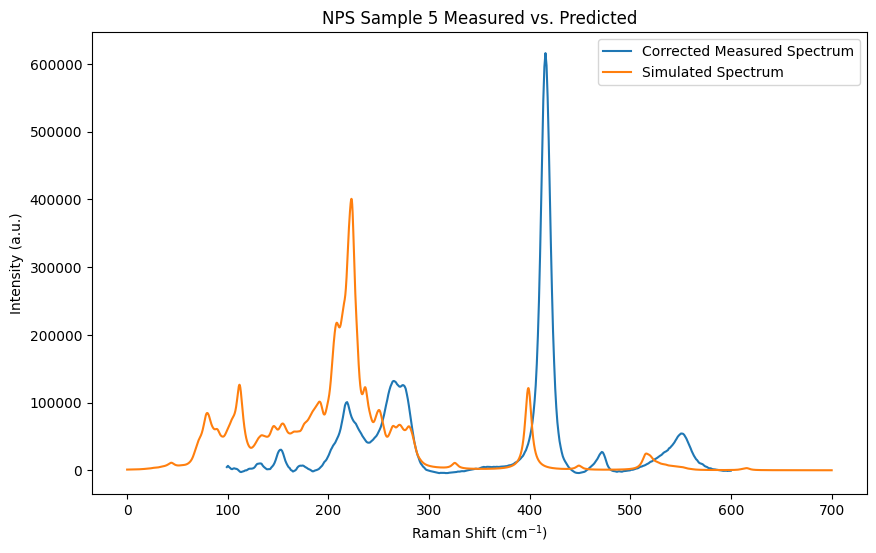

In [18]:
#Plotting Results
plt.figure(figsize=(10,6))

plt.plot(wna1, corrected1, label="Corrected Measured Spectrum")
plt.plot(x,80*spectrum, label="Simulated Spectrum")
plt.title('NPS Sample 5 Measured vs. Predicted')
plt.xlabel("Raman Shift (cm$^{-1}$)")
plt.ylabel("Intensity (a.u.)")
plt.legend()
plt.savefig('NPS_5_Comp.png',dpi=600)
plt.show()

In [ ]:
#Helper function to find peak indicies.
peaks, _ = find_peaks(intensitya1, prominence=2000)
#peaks = find_peaks(intensitya2, prominence=1000)
for peak in peaks:
  print(wna1[peak])

108.01
181.73
216.98
276.82
407.16
533.23
561.01


In [ ]:
print(len(wna1))
print(wna1[395])
print(wna1[468])

563
521.48
599.47


521.48
599.47
[[Model]]
    (((Model(lorentzian, prefix='v43_') + Model(lorentzian, prefix='v44_')) + Model(lorentzian, prefix='v46_')) + Model(lorentzian, prefix='v47_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 1059
    # data points      = 73
    # variables        = 12
    chi-square         = 18950555.8
    reduced chi-square = 310664.849
    Akaike info crit   = 934.082559
    Bayesian info crit = 961.568073
    R-squared          = 0.97025421
[[Variables]]
    v43_center:     530.698662 +/- 0.26985743 (0.05%) (init = 537)
    v44_center:     545.000000 +/- 170.226002 (31.23%) (init = 537)
    v46_center:     575.334724 +/- 2351006.84 (408632.88%) (init = 573)
    v47_center:     560.688575 +/- 0.33045325 (0.06%) (init = 575)
    v43_amplitude:  124684.847 +/- 28228.8446 (22.64%) (init = 5000)
    v44_amplitude:  712992.800 +/- 891277.420 (125.01%) (init = 5000)
    v46_amplitude:  0.04662989 +/- 2.7897e+13 (59827491110707272.00%) (init = 5000)

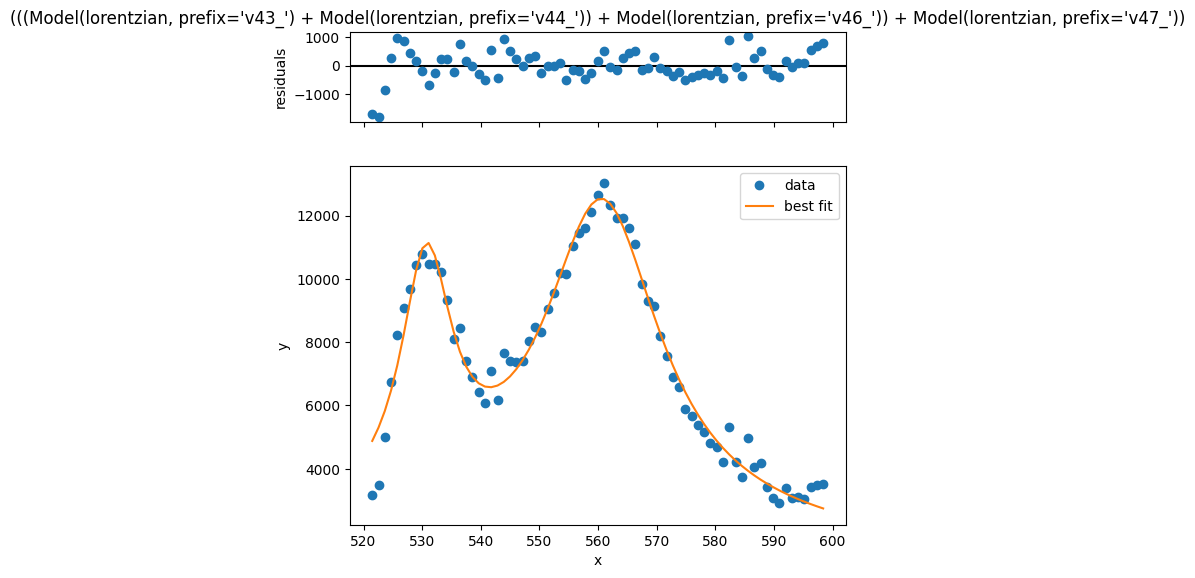

In [ ]:
#Fitting by Parts
#520 to 600
print(wna1[395])
print(wna1[468])

#There are four normal modes in this range - labeled according to famprikis 2021
model = LorentzianModel(prefix='v43_')
model += LorentzianModel(prefix='v44_')
model += LorentzianModel(prefix='v46_')
model += LorentzianModel(prefix='v47_')

#Instantiate the Parameters() object for lmfit
params = lmfit.Parameters()

#Adding the center position from theory
params.add('v43_center', value=537.0, min=520, max=545)
params.add('v44_center', value=537.0, min=520, max=545)
params.add('v46_center', value=573.0, min=550, max=590)
params.add('v47_center', value=575.0, min=550, max=590)

params.add('v43_amplitude', value=5000.0, min=0.0, max=1000000.0)
params.add('v44_amplitude', value=5000.0, min=0.0, max=1000000.0)
params.add('v46_amplitude', value=5000.0, min=0.0, max=1000000.0)
params.add('v47_amplitude', value=5000.0, min=0.0, max=1000000.0)

params.add('v43_sigma', value=10.0, min=0.0, max=100.0)
params.add('v44_sigma', value=10.0, min=0.0, max=100.0)
params.add('v46_sigma', value=10.0, min=0.0, max=100.0)
params.add('v47_sigma', value=10.0, min=0.0, max=100.0)

result = model.fit(corrected1[395:468], params, x=wna1[395:468])
result.plot()
print(result.fit_report())


#Plotting Results
#plt.figure(figsize=(10,6))


#plt.plot(wna1[375:468], corrected1[375:468], label="Corrected spectrum")

#plt.xlabel("Raman Shift (cm$^{-1}$)")
#plt.ylabel("Intensity (a.u.)")
#plt.legend()
#plt.show()

In [ ]:
print(peaks[4])

455


In [ ]:
#If the peak is not showing up above this may help.

#helper function to find index closest to my guess angle
def closest(lst, K):
    val=lst[min(range(len(lst)), key = lambda i: abs(lst[i]-K))]
    return lst.index(val)

#helper function to find index of nearest peak given a guess index
def peakfind(lst,K):
    temp=lst[K-15:K+15]
    maxval=max(temp)
    mindx=temp.index(maxval)
    #index = lst.index(maxval)
    index=K-15+mindx
    return index

In [ ]:
templst=wna2.tolist()
print(closest(templst,100))

48


In [ ]:
#This function fits a voigt function for a given index
#x is the list form of wavenumber (nparray), y is the list form of Int (nparray)
#Takes the index of the peak center, and number of points to the left and right of the center
# that should be considered in the fit.
def VPeakFit(WN,Int,icenter,nleft,nright):
    x=WN.tolist()
    y=Int.tolist()
    pki= icenter
    pkang= WN[pki]
    tempx=WN[pki-nleft:pki+nright]
    tempy=Int[pki-nleft:pki+nright]

    #Fitting
    #Define the model for a single peak
    model = VoigtModel(prefix='p0_')
    #Instantiate the Parameters() object for lmfit
    params = lmfit.Parameters()

    params.add(f'p0_center', value=pkang, min=pkang-20, max=pkang+20)
    params.add(f'p0_sigma', value=20, min=0.01)
    params.add(f'p0_gamma', value=20, min=0.01)
    params.add(f'p0_amplitude', value=1000000, min=0)

    result = model.fit(tempy, params, x=tempx)
    result.plot()
    print(result.fit_report())

In [ ]:
#This function fits a Lorentzian function for a given index
#x is the list form of wavenumber (nparray), y is the list form of Int (nparray)
#Takes the index of the peak center, and number of points to the left and right of the center
# that should be considered in the fit.
def LPeakFit(WN,Int,icenter,nleft,nright):
    x=WN.tolist()
    y=Int.tolist()
    pki= icenter
    pkang= WN[pki]
    tempx=WN[pki-nleft:pki+nright]
    tempy=Int[pki-nleft:pki+nright]

    #Fitting
    #Define the model for a single peak
    model = LorentzianModel(prefix='p0_')
    #Instantiate the Parameters() object for lmfit
    params = lmfit.Parameters()

    params.add(f'p0_center', value=pkang, min=pkang-20, max=pkang+20)
    params.add(f'p0_sigma', value=20, min=0.01)
    #params.add(f'p0_gamma', value=20, min=0.01)
    params.add(f'p0_amplitude', value=1000000, min=0)

    result = model.fit(tempy, params, x=tempx)
    #result.plot()
    #print(result.fit_report())
    return result

In [ ]:
#Same as above but for jointly fitting the two peaks that should be around 500
# One at ~525 and the other at ~580
# icenters is a list of two peak center indicies - lower index first.
def L2PeakFit(WN,Int,icenters,nleft,nright):
    x=WN.tolist()
    y=Int.tolist()
    pki1= icenters[0]
    pkang1= WN[pki1]
    pki2= icenters[1]
    pkang2= WN[pki2]
    tempx=WN[pki1-nleft:pki2+nright]
    tempy=Int[pki1-nleft:pki2+nright]

    #Fitting
    #Define the model for a single peak
    model = LorentzianModel(prefix='p0_')
    model += LorentzianModel(prefix='p1_')
    #Instantiate the Parameters() object for lmfit
    params = lmfit.Parameters()

    params.add(f'p0_center', value=pkang1, min=pkang1-10, max=pkang1+10)
    params.add(f'p0_sigma', value=20, min=0.01)
    params.add(f'p0_amplitude', value=1000000, min=0)
    params.add(f'p1_center', value=pkang2, min=pkang2-20, max=pkang2+20)
    params.add(f'p1_sigma', value=20, min=0.01)
    params.add(f'p1_amplitude', value=1000000, min=0)


    result = model.fit(tempy, params, x=tempx)
    return result

[[Model]]
    Model(lorentzian, prefix='p0_')
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 43
    # data points      = 20
    # variables        = 3
    chi-square         = 1.3638e+08
    reduced chi-square = 8022265.48
    Akaike info crit   = 320.704250
    Bayesian info crit = 323.691447
    R-squared          = 0.99685739
[[Variables]]
    p0_center:     142.686672 +/- 0.04140160 (0.03%) (init = 142.98)
    p0_sigma:      14.2790543 +/- 0.12030103 (0.84%) (init = 20)
    p0_amplitude:  19038875.7 +/- 129245.401 (0.68%) (init = 1000000)
[[Correlations]] (unreported correlations are < 0.100)
    C(p0_sigma, p0_amplitude) = +0.9675


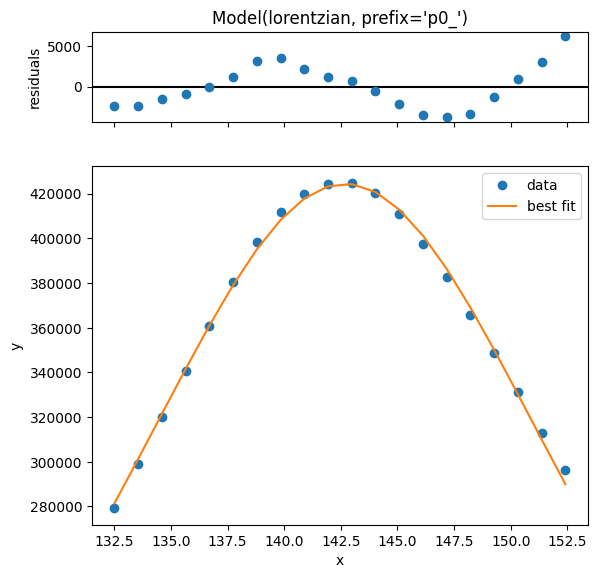

In [ ]:
Peak1 = LPeakFit(wna2, intensitya2,peaks[0],10,10)
Peak1.plot()
print(Peak1.fit_report())

[[Model]]
    Model(lorentzian, prefix='p0_')
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 40
    # data points      = 20
    # variables        = 3
    chi-square         = 681568.941
    reduced chi-square = 40092.2906
    Akaike info crit   = 214.728408
    Bayesian info crit = 217.715605
    R-squared          = 0.99729335
[[Variables]]
    p0_center:     237.168389 +/- 0.03569031 (0.02%) (init = 237.25)
    p0_sigma:      36.9580826 +/- 0.24575495 (0.66%) (init = 20)
    p0_amplitude:  18253050.0 +/- 115580.609 (0.63%) (init = 1000000)
[[Correlations]] (unreported correlations are < 0.100)
    C(p0_sigma, p0_amplitude)  = +0.9989
    C(p0_center, p0_amplitude) = +0.1487
    C(p0_center, p0_sigma)     = +0.1459


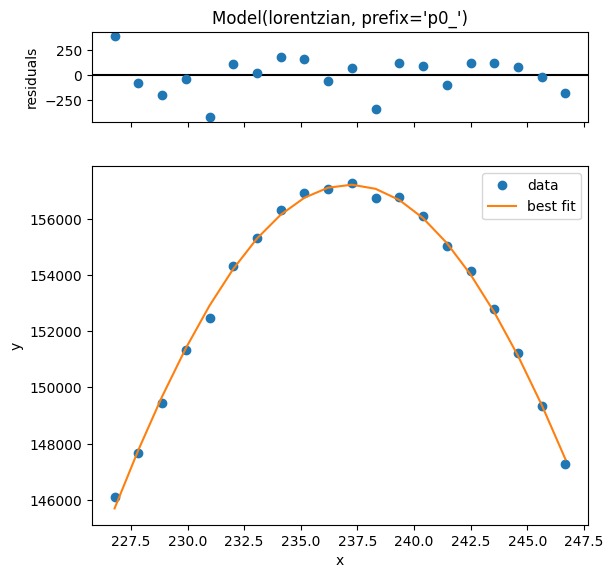

In [ ]:
Peak2 = LPeakFit(wna2, intensitya2,peaks[1],10,10)
Peak2.plot()
print(Peak2.fit_report())

[[Model]]
    Model(lorentzian, prefix='p0_')
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 42
    # data points      = 20
    # variables        = 3
    chi-square         = 4909134.28
    reduced chi-square = 288772.605
    Akaike info crit   = 254.217518
    Bayesian info crit = 257.204715
    R-squared          = 0.97668933
[[Variables]]
    p0_center:     314.504104 +/- 0.11151625 (0.04%) (init = 315.81)
    p0_sigma:      31.9687295 +/- 0.65346351 (2.04%) (init = 20)
    p0_amplitude:  10672615.4 +/- 204849.851 (1.92%) (init = 1000000)
[[Correlations]] (unreported correlations are < 0.100)
    C(p0_sigma, p0_amplitude)  = +0.9981
    C(p0_center, p0_amplitude) = -0.2502
    C(p0_center, p0_sigma)     = -0.2441


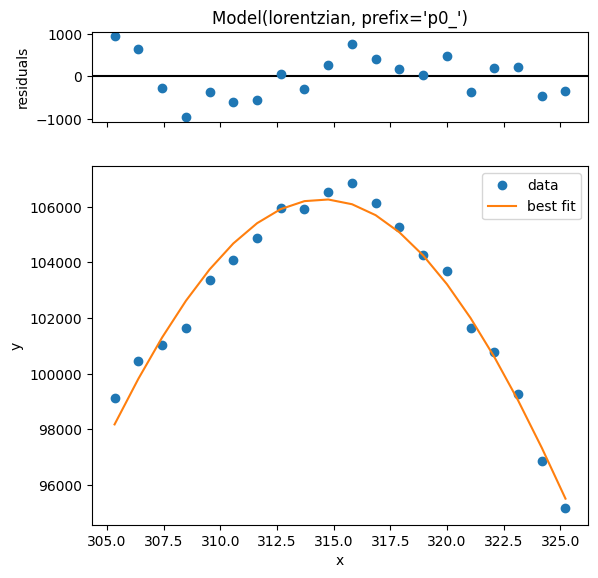

In [ ]:
Peak3 = LPeakFit(wna2, intensitya2,peaks[2],10,10)
Peak3.plot()
print(Peak3.fit_report())

[[Model]]
    Model(lorentzian, prefix='p0_')
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 21
    # data points      = 20
    # variables        = 3
    chi-square         = 888701.442
    reduced chi-square = 52276.5554
    Akaike info crit   = 220.035687
    Bayesian info crit = 223.022884
    R-squared          = 0.93552292
[[Variables]]
    p0_center:     458.240699 +/- 0.32416025 (0.07%) (init = 456.16)
    p0_sigma:      51.4493136 +/- 2.29103861 (4.45%) (init = 20)
    p0_amplitude:  8006318.89 +/- 348865.845 (4.36%) (init = 1000000)
[[Correlations]] (unreported correlations are < 0.100)
    C(p0_sigma, p0_amplitude)  = +0.9997
    C(p0_center, p0_amplitude) = +0.6807
    C(p0_center, p0_sigma)     = +0.6737


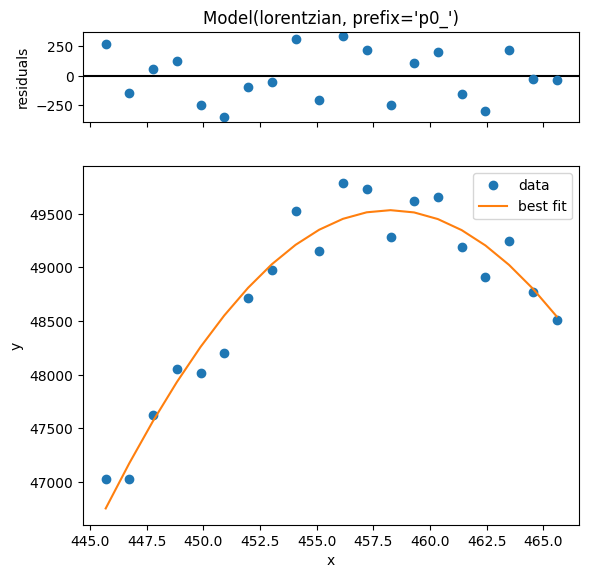

In [ ]:
Peak4 = LPeakFit(wna2, intensitya2,peaks[3],10,10)
Peak4.plot()
print(Peak4.fit_report())

[[Model]]
    (Model(lorentzian, prefix='p0_') + Model(lorentzian, prefix='p1_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 81
    # data points      = 81
    # variables        = 6
    chi-square         = 6417690.98
    reduced chi-square = 85569.2130
    Akaike info crit   = 925.689703
    Bayesian info crit = 940.056398
    R-squared          = 0.99986313
[[Variables]]
    p0_center:     524.829366 +/- 0.05031106 (0.01%) (init = 526.34)
    p0_sigma:      26.8518742 +/- 0.24154575 (0.90%) (init = 20)
    p0_amplitude:  8059724.33 +/- 165122.388 (2.05%) (init = 1000000)
    p1_center:     574.744300 +/- 0.87396385 (0.15%) (init = 579.76)
    p1_sigma:      54.6332460 +/- 2.07643099 (3.80%) (init = 20)
    p1_amplitude:  5713444.79 +/- 302467.959 (5.29%) (init = 1000000)
[[Correlations]] (unreported correlations are < 0.100)
    C(p1_sigma, p1_amplitude)     = +0.9903
    C(p0_amplitude, p1_amplitude) = -0.9791
    C(p0_sigma, p0_amplitude)     = +0

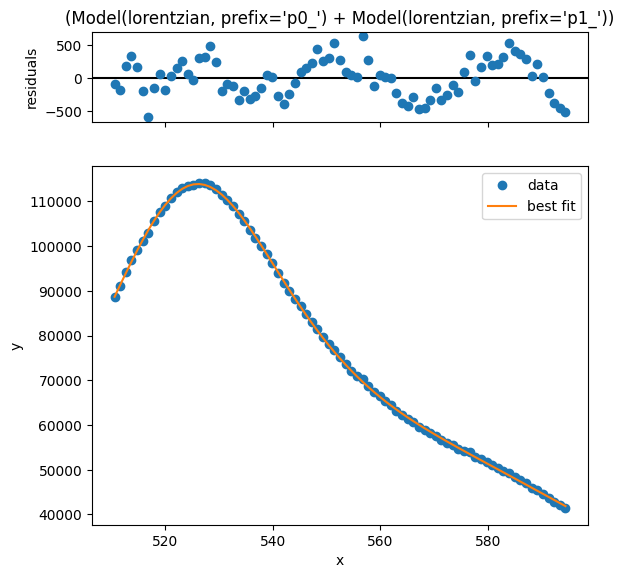

In [ ]:
#The peaks at 525 and 580 near the indices 455 and 506.
Peaks5_6 = L2PeakFit(wna2, intensitya2,[455,506],15,15)
Peaks5_6.plot()
print(Peaks5_6.fit_report())

[[Model]]
    Model(lorentzian, prefix='p0_')
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 25
    # data points      = 80
    # variables        = 3
    chi-square         = 4193373.87
    reduced chi-square = 54459.4009
    Akaike info crit   = 875.359164
    Bayesian info crit = 882.505244
    R-squared          = 0.95377419
[[Variables]]
    p0_center:     782.351535 +/- 0.28297241 (0.04%) (init = 784)
    p0_sigma:      126.914099 +/- 1.68630259 (1.33%) (init = 20)
    p0_amplitude:  13902603.6 +/- 173143.026 (1.25%) (init = 1000000)
[[Correlations]] (unreported correlations are < 0.100)
    C(p0_sigma, p0_amplitude) = +0.9981


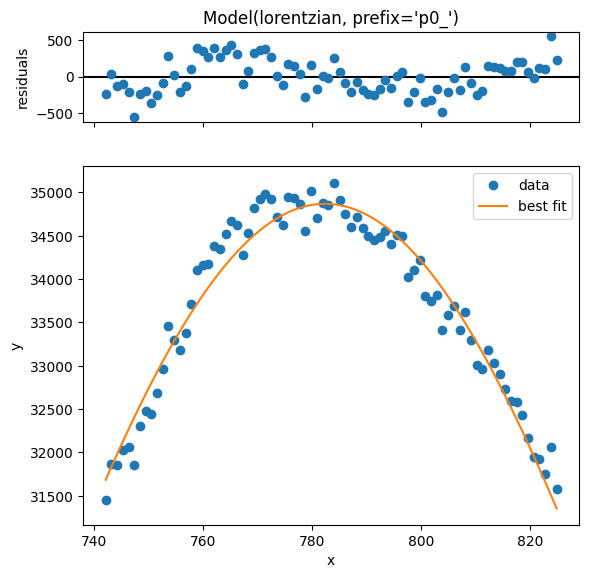

In [ ]:
Peak7 = LPeakFit(wna2, intensitya2,peaks[5],40,40)
Peak7.plot()
print(Peak7.fit_report())

In [ ]:
ysim=np.zeros(1000)
xsim=np.linspace(200,1000,1000)

In [ ]:
def lorentzian(x, x0, sigma, amplitude):
        return amplitude/np.pi * (sigma / ((x - x0)**2 + sigma**2))

In [ ]:
Peak7.params.valuesdict()

{'p0_center': 782.3515354485635,
 'p0_sigma': 126.91409929009359,
 'p0_amplitude': 13902603.63717527}

In [ ]:
ysim=np.zeros(1000)
xsim=np.linspace(50,1000,1000)

PeakList = [Peak1, Peak2, Peak3, Peak4,Peak7]
#PeakList = [Peak7]
for peak in PeakList:
    td = peak.params.valuesdict()
    ysim += lorentzian(xsim, td['p0_center'], td['p0_sigma'], td['p0_amplitude'])


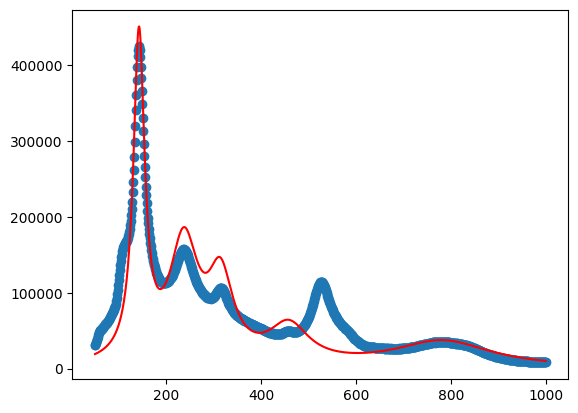

In [ ]:
plt.scatter(wna2,intensitya2)
plt.plot(xsim,ysim,'r')
plt.show()

In [ ]:
#Ok so we need to do this fitting jointly...

In [ ]:
#Let's make a list of values
pvlst=[]

#peaks 1-4
PL = [Peak1, Peak2, Peak3, Peak4]
for peak in PL:
    tdl = list(peak.params.valuesdict().values())
    pvlst.append(tdl)
#peaks 5-6
pvlst.append(list(Peaks5_6.params.valuesdict().values())[:3])
pvlst.append(list(Peaks5_6.params.valuesdict().values())[3:])
#peak 7
pvlst.append(list(Peak7.params.valuesdict().values()))

print(pvlst)

[[142.6866718861929, 14.279054337673143, 19038875.659615282], [237.16838920136195, 36.95808264060001, 18253050.017969664], [314.5041036109601, 31.968729489874075, 10672615.387802968], [458.2406991014487, 51.449313585282155, 8006318.891920026], [524.8293662755078, 26.851874238561344, 8059724.330455682], [574.7443000361253, 54.633246012861555, 5713444.793889935], [782.3515354485635, 126.91409929009359, 13902603.63717527]]


In [ ]:
print(len(pvlst))

7


[[Model]]
    ((((((Model(lorentzian, prefix='p1_') + Model(lorentzian, prefix='p2_')) + Model(lorentzian, prefix='p3_')) + Model(lorentzian, prefix='p4_')) + Model(lorentzian, prefix='p5_')) + Model(lorentzian, prefix='p6_')) + Model(lorentzian, prefix='p7_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 29
    # data points      = 908
    # variables        = 21
    chi-square         = 2.4933e+12
    reduced chi-square = 2.8109e+09
    Akaike info crit   = 19775.9169
    Bayesian info crit = 19876.9530
    R-squared          = 0.35271008
[[Variables]]
    p1_center:     142.686672 +/- 2357.18975 (1652.00%) (init = 142.6867)
    p1_sigma:      128.418005 +/- 1.0111e-07 (0.00%) (init = 128.418)
    p1_amplitude:  19038875.7 +/- 1.1832e+10 (62147.67%) (init = 1.903888e+07)
    p2_center:     237.168389 +/- 64019.5779 (26993.30%) (init = 237.1684)
    p2_sigma:      213.451550 +/- 3.8512e-06 (0.00%) (init = 213.4516)
    p2_amplitude:  18253050.0 +/- 2.62

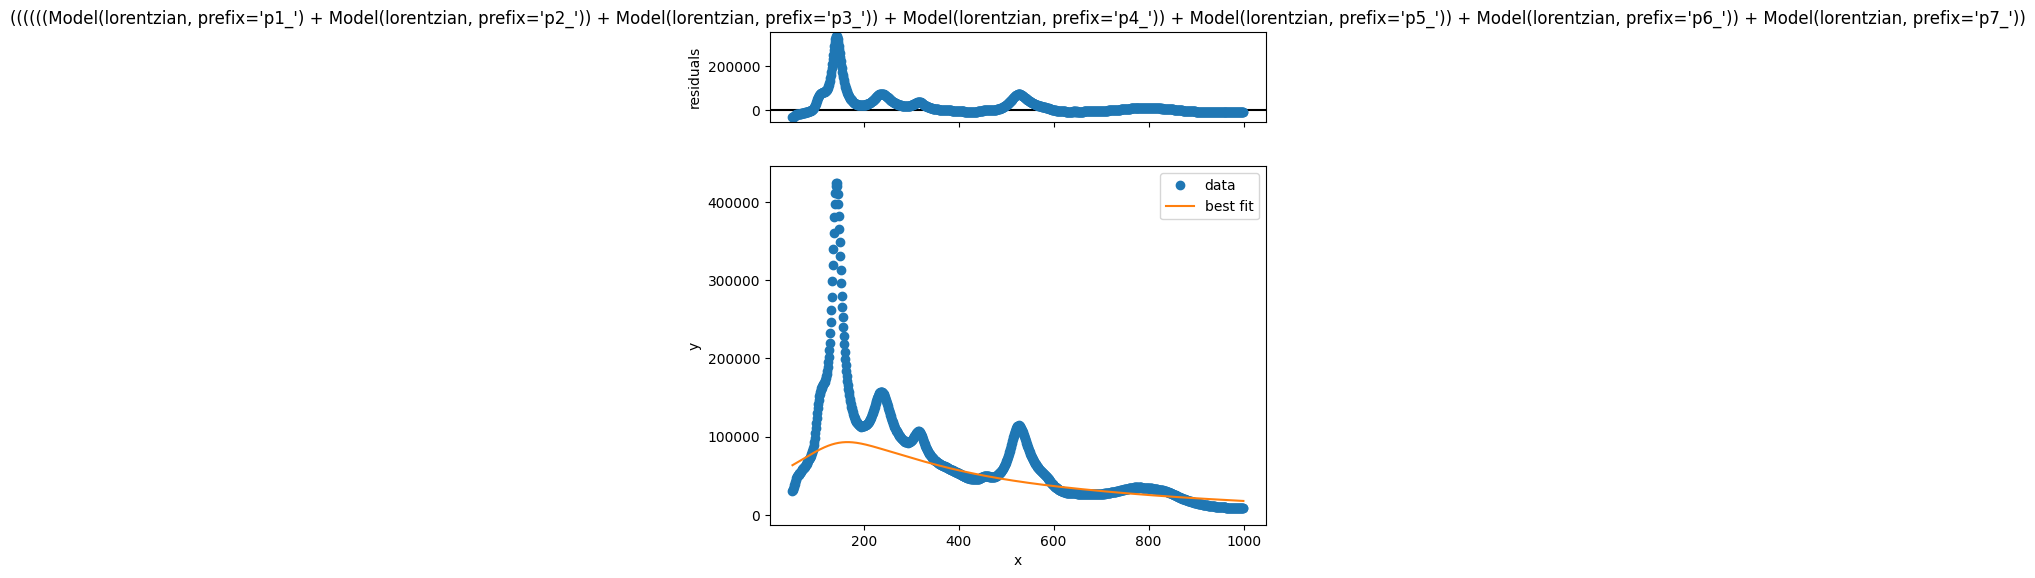

In [ ]:
#This first one is the required
model = LorentzianModel(prefix='p1_')
for i in range(2, 8):
    model += LorentzianModel(prefix=f'p{i}_')
#Instantiate the Parameters() object for lmfit
params = lmfit.Parameters()
for i in range(1,8):
    params.add(f'p{i}_center', value=pvlst[i-1][0], min=pvlst[i-1][0]*.98, max=pvlst[i-1][0]*1.02)
    params.add(f'p{i}_sigma', value=pvlst[i-1][1], min=pvlst[i-1][0]*.9, max=pvlst[i-1][0]*1.1)
    params.add(f'p{i}_amplitude', value=pvlst[i-1][2], min=pvlst[i-1][2]*0.5, max=pvlst[i-1][2]*1.5)

result = model.fit(intensitya2, params, x=wna2)
result.plot()
print(result.fit_report())

[[Model]]
    ((((((Model(lorentzian, prefix='p1_') + Model(lorentzian, prefix='p2_')) + Model(lorentzian, prefix='p3_')) + Model(lorentzian, prefix='p4_')) + Model(lorentzian, prefix='p5_')) + Model(lorentzian, prefix='p6_')) + Model(lorentzian, prefix='p7_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 912
    # data points      = 833
    # variables        = 14
    chi-square         = 2.5599e+10
    reduced chi-square = 31256014.2
    Akaike info crit   = 14389.5638
    Bayesian info crit = 14455.7142
    R-squared          = 0.99282833
##  Warning: uncertainties could not be estimated:
    p2_sigma:      at boundary
    p3_sigma:      at boundary
    p4_sigma:      at boundary
    p5_sigma:      at boundary
    p6_sigma:      at boundary
[[Variables]]
    p1_center:     142.6867 (fixed)
    p1_sigma:      15.6895205 (init = 14.27905)
    p1_amplitude:  18917525.3 (init = 1.903888e+07)
    p2_center:     237.1684 (fixed)
    p2_sigma:      44.349696

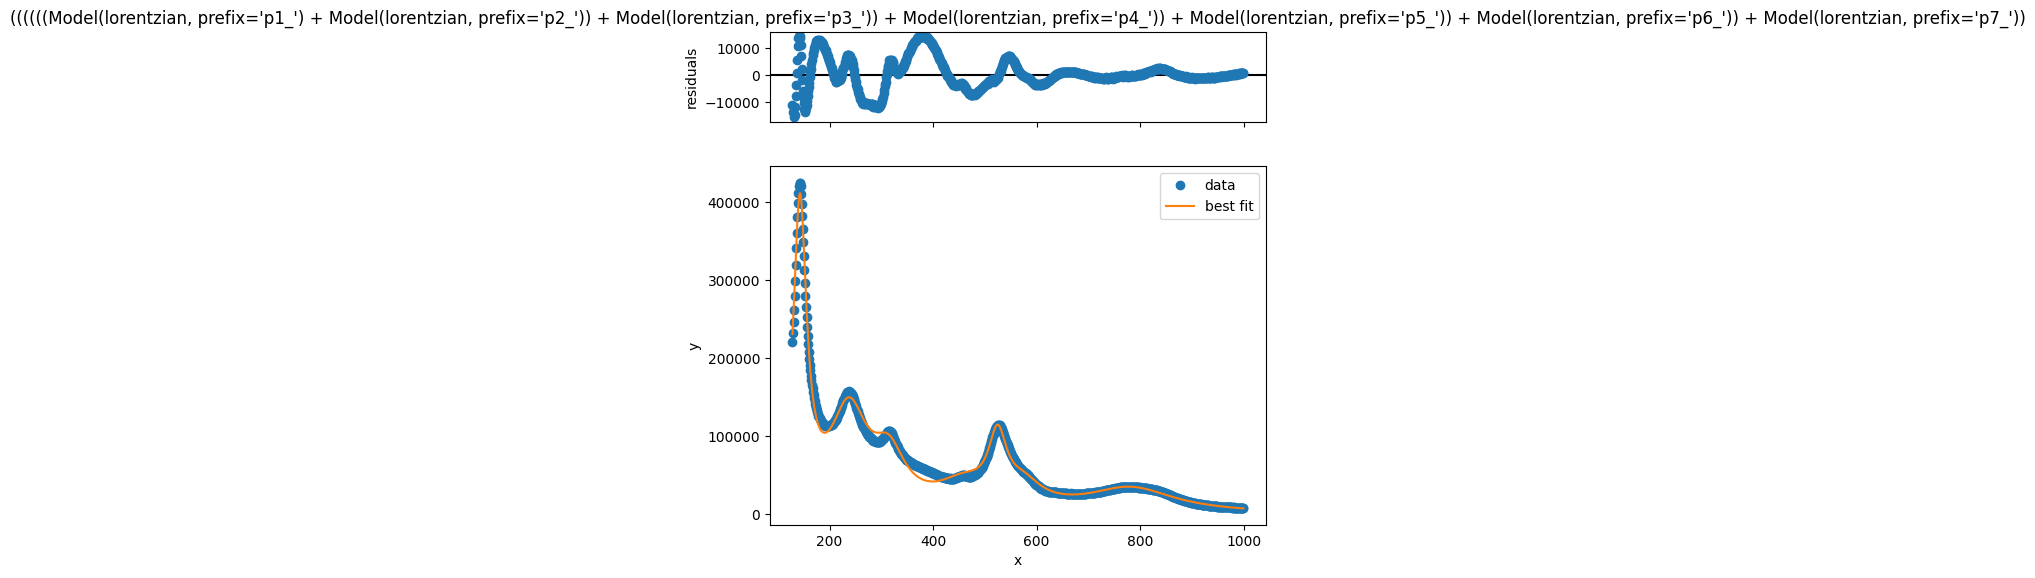

In [ ]:
#This first one is the required
model = LorentzianModel(prefix='p1_')
for i in range(2, 8):
    model += LorentzianModel(prefix=f'p{i}_')
#Instantiate the Parameters() object for lmfit
params = lmfit.Parameters()
for i in range(1,8):
    params.add(f'p{i}_center', value=pvlst[i-1][0], vary=False)
    params.add(f'p{i}_sigma', value=pvlst[i-1][1], min=pvlst[i-1][1]*0.8, max=pvlst[i-1][1]*1.2)
    params.add(f'p{i}_amplitude', value=pvlst[i-1][2], min=pvlst[i-1][2]*0.5, max=pvlst[i-1][2]*1.5)

result = model.fit(intensitya2[75:], params, x=wna2[75:])
result.plot()
print(result.fit_report())

[[Model]]
    (((((((Model(lorentzian, prefix='p1_') + Model(lorentzian, prefix='p2_')) + Model(lorentzian, prefix='p3_')) + Model(lorentzian, prefix='p4_')) + Model(lorentzian, prefix='p5_')) + Model(lorentzian, prefix='p6_')) + Model(lorentzian, prefix='p7_')) + Model(lorentzian, prefix='p8_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 459
    # data points      = 833
    # variables        = 17
    chi-square         = 1.1569e+10
    reduced chi-square = 14178243.4
    Akaike info crit   = 13734.0177
    Bayesian info crit = 13814.3433
    R-squared          = 0.99675873
[[Variables]]
    p1_center:     142.6867 (fixed)
    p1_sigma:      15.6737631 +/- 0.09489177 (0.61%) (init = 14.27905)
    p1_amplitude:  18931435.0 +/- 97754.0479 (0.52%) (init = 1.903888e+07)
    p2_center:     237.1684 (fixed)
    p2_sigma:      43.8647554 +/- 0.53991189 (1.23%) (init = 36.95808)
    p2_amplitude:  17693612.1 +/- 198601.924 (1.12%) (init = 1.825305e+07)
    p3

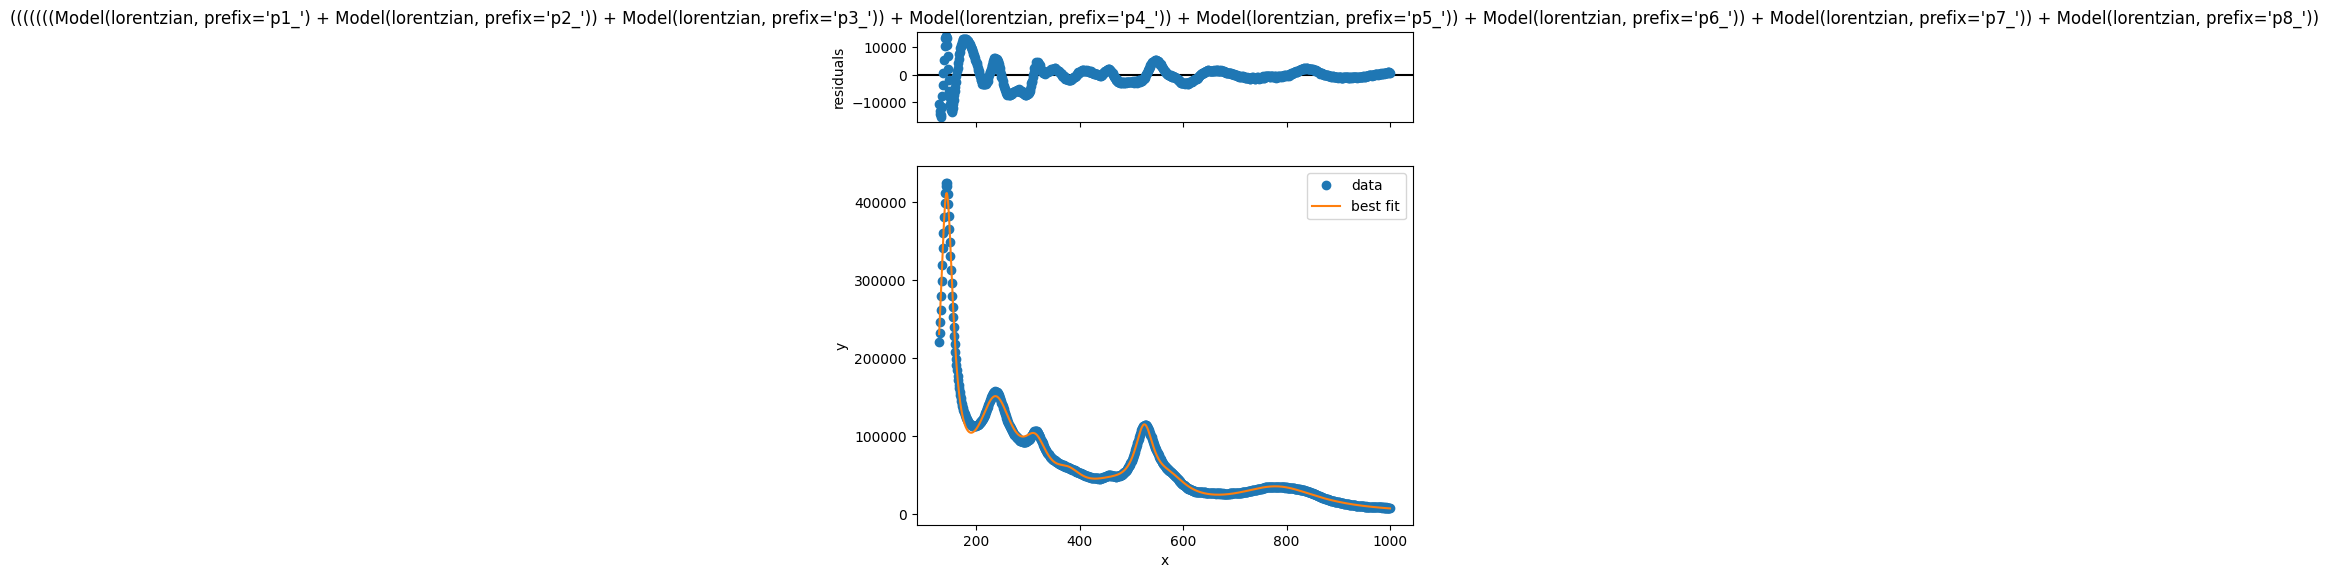

In [ ]:
#This first one is the required
model = LorentzianModel(prefix='p1_')
for i in range(2, 9):
    model += LorentzianModel(prefix=f'p{i}_')
#Instantiate the Parameters() object for lmfit
params = lmfit.Parameters()
for i in range(1,8):
    params.add(f'p{i}_center', value=pvlst[i-1][0], vary=False)
    params.add(f'p{i}_sigma', value=pvlst[i-1][1], min=pvlst[i-1][1]*0.8, max=pvlst[i-1][1]*1.2)
    params.add(f'p{i}_amplitude', value=pvlst[i-1][2], min=pvlst[i-1][2]*0.5, max=pvlst[i-1][2]*1.5)

#There seems to be something going on around ~390 that needs to be accounted for...
params.add(f'p8_center', value=390, min=360, max=420)
params.add(f'p8_sigma', value=20, min=0.01)
params.add(f'p8_amplitude', value=1000000, min=0)


result = model.fit(intensitya2[75:], params, x=wna2[75:])
result.plot()
print(result.fit_report())

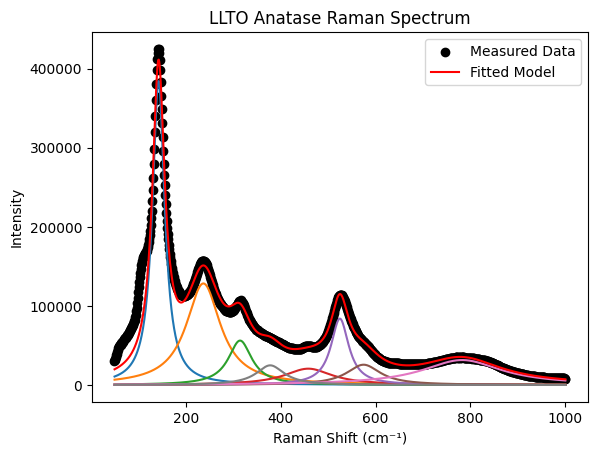

In [ ]:
#Make a nice plot

ysim=np.zeros(1000)
xsim=np.linspace(50,1000,1000)

rdict = result.params.valuesdict()

plt.xlabel("Raman Shift (cm⁻¹)")
plt.ylabel("Intensity")
plt.title("LLTO Anatase Raman Spectrum")
plt.scatter(wna2,intensitya2, c='k', label='Measured Data')
for i in range(1,9):
  y= lorentzian(xsim, rdict[f'p{i}_center'], rdict[f'p{i}_sigma'], rdict[f'p{i}_amplitude'])
  ysim+=y
  plt.plot(xsim,y)
plt.plot(xsim,ysim,'r', label='Fitted Model')
plt.legend()
plt.savefig('LLTO_Anatase_Raman_FullFit.png',dpi=600)
plt.show()

In [ ]:
rdict = result.params.valuesdict()
print(rdict['p1_center'])

142.6866718861929


In [ ]:
for i in range(1, 8):
  print(i)

1
2
3
4
5
6
7


In [ ]:
model = VoigtModel(prefix='p0_')
for i in range(1, 8):
    model += VoigtModel(prefix=f'p{i}_')
#Instantiate the Parameters() object for lmfit
params = lmfit.Parameters()

for i in range(len(initial_centers)):
    params.add(f'p{i}_center', value=initial_centers[i], min=initial_centers[i]-20, max=initial_centers[i]+20)
    params.add(f'p{i}_sigma', value=20, min=0.1)
    params.add(f'p{i}_gamma', value=20, min=0.1)
    params.add(f'p{i}_amplitude', value=1000000, min=0)

result = model.fit(intensity, params, x=wn)
result.plot()
print(result.fit_report())

NameError: name 'initial_centers' is not defined

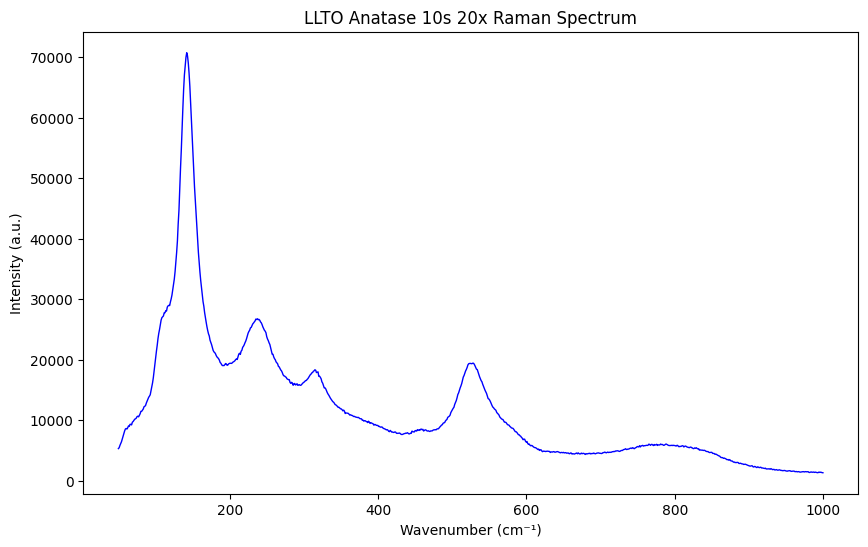

In [ ]:
#Plot the data
plt.figure(figsize=(10, 6))
plt.plot(wna1, intensitya1, 'b-', linewidth=1)
plt.xlabel('Wavenumber (cm⁻¹)')
plt.ylabel('Intensity (a.u.)')
plt.title('LLTO Anatase 10s 20x Raman Spectrum')
#plt.xlim(600,700)
#plt.ylim(250,450)
#plt.savefig('LLTO_Raman_W.png',dpi=600)
plt.show()

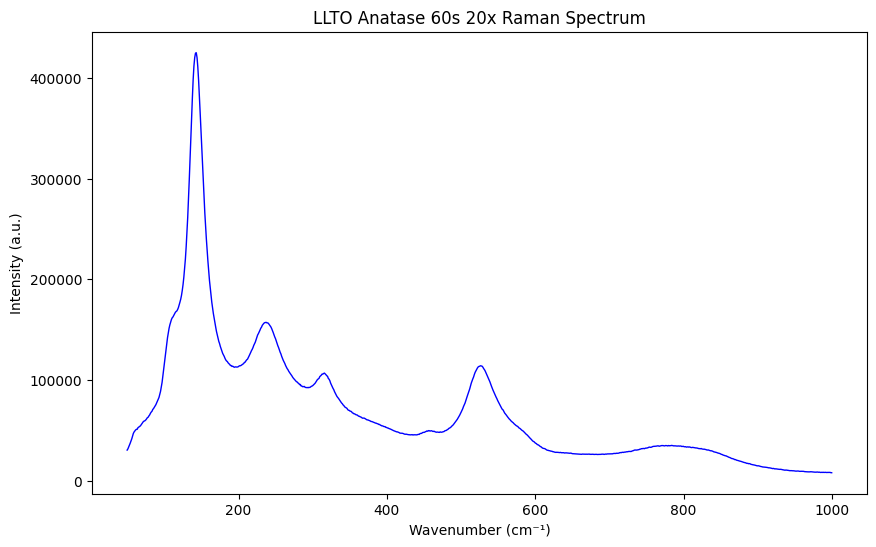

In [ ]:
#Plot the data
plt.figure(figsize=(10, 6))
plt.plot(wna2, intensitya2, 'b-', linewidth=1)
plt.xlabel('Wavenumber (cm⁻¹)')
plt.ylabel('Intensity (a.u.)')
plt.title('LLTO Anatase 60s 20x Raman Spectrum')
#plt.xlim(600,700)
#plt.ylim(250,450)
#plt.savefig('LLTO_Raman_W.png',dpi=600)
plt.show()

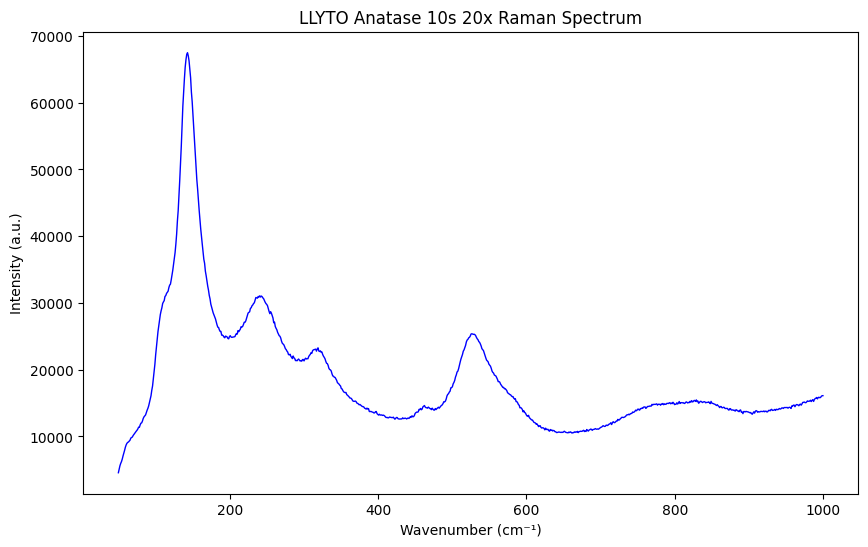

In [ ]:
#Plot the data
plt.figure(figsize=(10, 6))
plt.plot(wny1, intensityy1, 'b-', linewidth=1)
plt.xlabel('Wavenumber (cm⁻¹)')
plt.ylabel('Intensity (a.u.)')
plt.title('LLYTO Anatase 10s 20x Raman Spectrum')
#plt.xlim(600,700)
#plt.ylim(250,450)
#plt.savefig('LLTO_Raman_Y2.png',dpi=600)
plt.show()

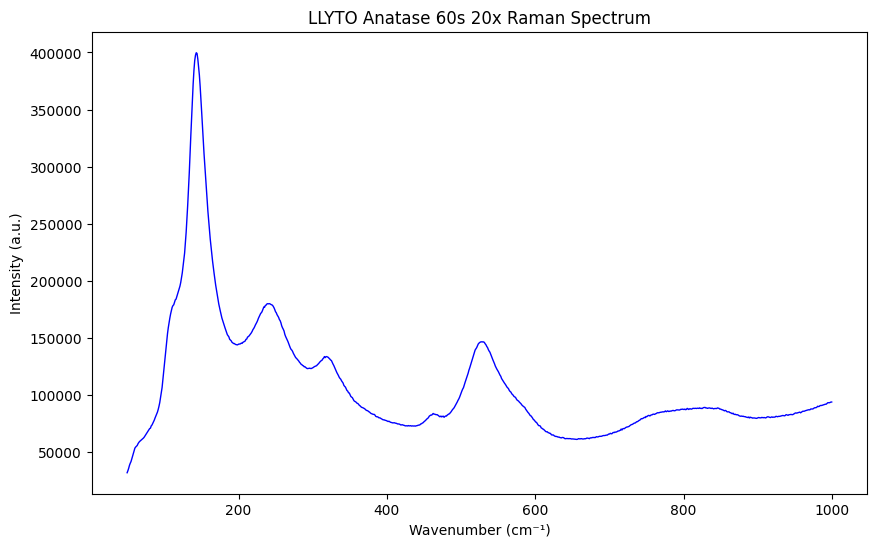

In [ ]:
#Plot the data
plt.figure(figsize=(10, 6))
plt.plot(wny2, intensityy2, 'b-', linewidth=1)
plt.xlabel('Wavenumber (cm⁻¹)')
plt.ylabel('Intensity (a.u.)')
plt.title('LLYTO Anatase 60s 20x Raman Spectrum')
#plt.xlim(600,700)
#plt.ylim(250,450)
#plt.savefig('LLTO_Raman_Y2.png',dpi=600)
plt.show()

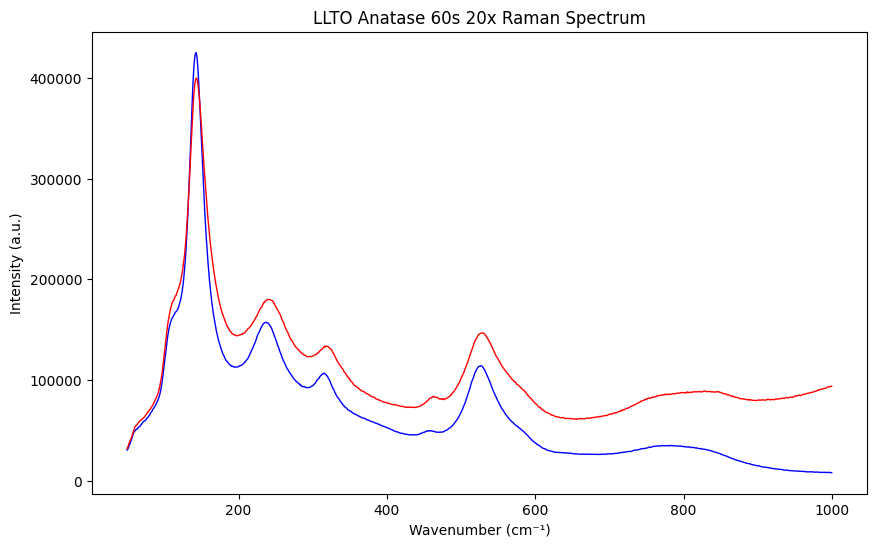

In [ ]:
#Plot the data
plt.figure(figsize=(10, 6))
plt.plot(wna2, intensitya2, 'b-', linewidth=1)
plt.plot(wny2, intensityy2, 'r-', linewidth=1)
plt.xlabel('Wavenumber (cm⁻¹)')
plt.ylabel('Intensity (a.u.)')
plt.title('LLTO Anatase 60s 20x Raman Spectrum')
#plt.xlim(600,700)
#plt.ylim(250,450)
#plt.savefig('LLTO_Raman_W.png',dpi=600)
plt.show()

In [ ]:
#helper function to find index closest to my guess angle
def closest(lst, K):
    val=lst[min(range(len(lst)), key = lambda i: abs(lst[i]-K))]
    return lst.index(val)

#helper function to find index of nearest peak given a guess index
def peakfind(lst,K):
    temp=lst[K-15:K+15]
    maxval=max(temp)
    mindx=temp.index(maxval)
    #index = lst.index(maxval)
    index=K-15+mindx
    return index

#This function returns the Voigt FWHM given best fit sigma and gamma.
def VoigtFWHM(sigma,gamma):
    fN=2.*sigma*np.sqrt(2.*np.log(2.))
    fC=2.*gamma
    VB = 0.5346*fC+np.sqrt(0.2166*(fC**2.)+(fN**2.))
    return VB



def fitVoigt(x,sigma,gamma,a,offset):
    return a*voigt_profile(x-offset,sigma,gamma)


#This function does a lot
#x is the list form of Ang (nparray), y is the list form of Int (nparray)
def GetFWHM(Ang,Int,center,nleft,nright):
    x=Ang.tolist()
    y=Int.tolist()
    pki= peakfind(y,closest(x,center))
    pkang= Ang[pki]
    tempx=Ang[pki-nleft:pki+nright]
    tempy=Int[pki-nleft:pki+nright]
    tempx=tempx-pkang

    popt, pcov = curve_fit(fitVoigt, tempx, tempy,maxfev=4000)
    print(pkang-popt[3])

    temptitle= 'Raman peak centered at Wavenumber = '+str(pkang)[0:6]

    xsim=np.linspace(tempx[0],tempx[-1],100)
    plt.scatter(tempx,tempy)
    plt.plot(xsim,fitVoigt(xsim,*popt),'r')
    plt.title(temptitle)
    plt.xlabel('Wavenumber offset from peak center (cm-1)')
    plt.ylabel('Intensity (Arbitrary Units)')
    plt.show()

    sigma = popt[0]
    gamma = popt[1]
    VFW= VoigtFWHM(sigma,gamma)
    #print(popt[0:2])
    #print(popt[3])

    return [pkang,VFW,pcov,popt]


#This function does a lot
#x is the list form of Ang (nparray), y is the list form of Int (nparray)
def FitVoigt(Ang,Int,center,nleft,nright):
    x=Ang.tolist()
    y=Int.tolist()
    pki= peakfind(y,closest(x,center))
    pkang= Ang[pki]
    tempx=Ang[pki-nleft:pki+nright]
    tempy=Int[pki-nleft:pki+nright]
    print(tempx)
    print(tempy)
    tempx=tempx-pkang

    #popt, pcov = curve_fit(fitVoigt, tempx, tempy,maxfev=4000)
    #print(popt)




In [ ]:
FitVoigt(wna2, intensitya2,143,10,10)

[132.51 133.56 134.6  135.65 136.7  137.75 138.79 139.84 140.89 141.94
 142.98 144.03 145.08 146.13 147.17 148.22 149.27 150.32 151.36 152.41]
[279125. 298904. 319836. 340541. 360945. 380277. 398152. 411700. 419990.
 424465. 424905. 420125. 410688. 397641. 382543. 365680. 348722. 331016.
 312982. 296144.]


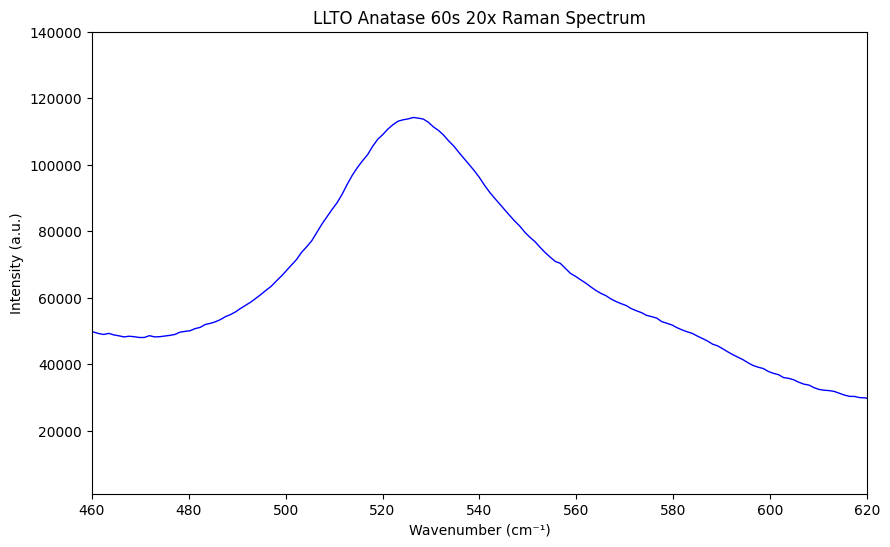

In [ ]:
#Plot the data
plt.figure(figsize=(10, 6))
plt.plot(wna2, intensitya2, 'b-', linewidth=1)
plt.xlabel('Wavenumber (cm⁻¹)')
plt.ylabel('Intensity (a.u.)')
plt.title('LLTO Anatase 60s 20x Raman Spectrum')
plt.xlim(460,620)
plt.ylim(1000,140000)
#plt.savefig('LLTO_Raman_W.png',dpi=600)
plt.show()

143.27332814433848


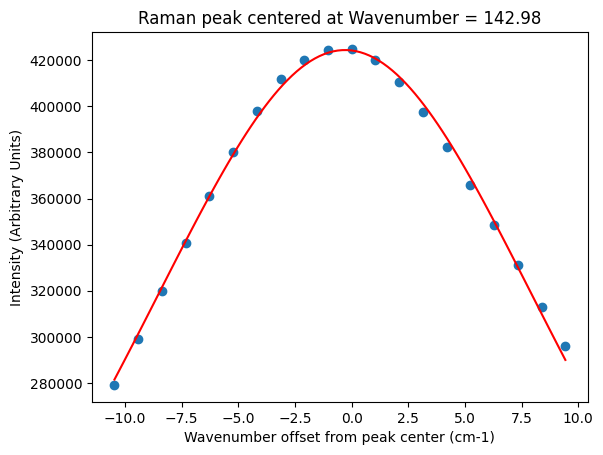

In [ ]:
Rama1= GetFWHM(wna2, intensitya2,143,10,10)

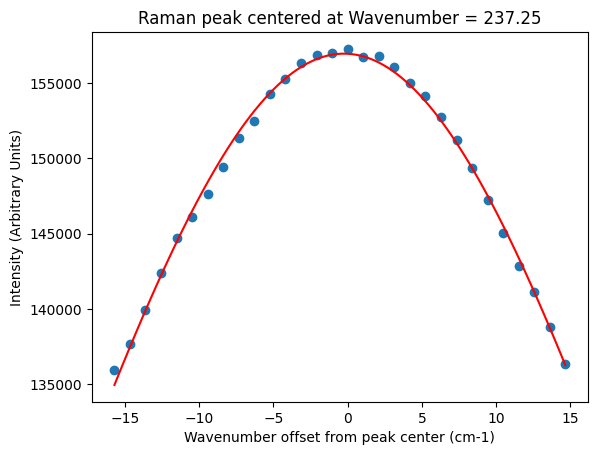

In [ ]:
Rama2= GetFWHM(wna2, intensitya2,237,15,15)

317.1158965968182


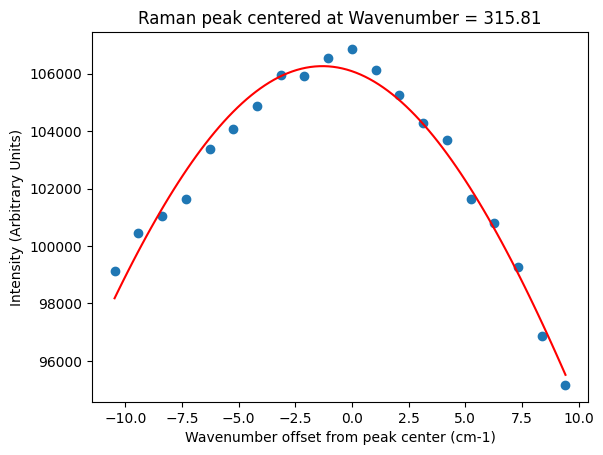

In [ ]:
Rama3= GetFWHM(wna2, intensitya2,316,10,10)

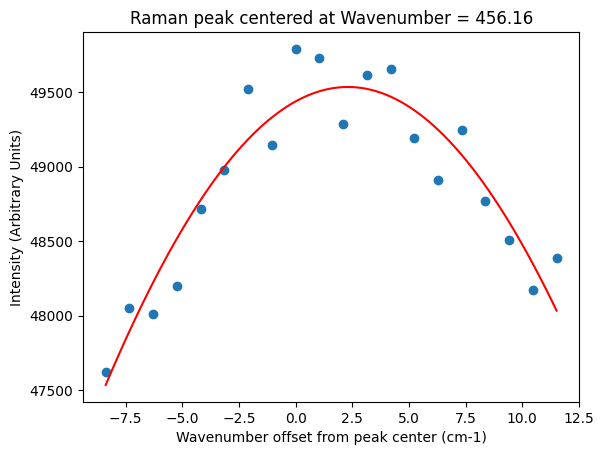

In [ ]:
Rama4= GetFWHM(wna2, intensitya2,456,8,12)

In [ ]:
Rama3

[np.float64(315.81),
 np.float64(63.93767768481976),
 array([[ 2.06183182e+06, -4.56424139e+03, -9.15169235e+08,
         -1.19656960e+01],
        [-4.56424139e+03,  1.05575089e+01,  2.16786086e+06,
          7.58492961e-03],
        [-9.15169235e+08,  2.16786086e+06,  4.50796689e+11,
         -7.62821935e+02],
        [-1.19656960e+01,  7.58492961e-03, -7.62821935e+02,
          1.32825911e-02]])]

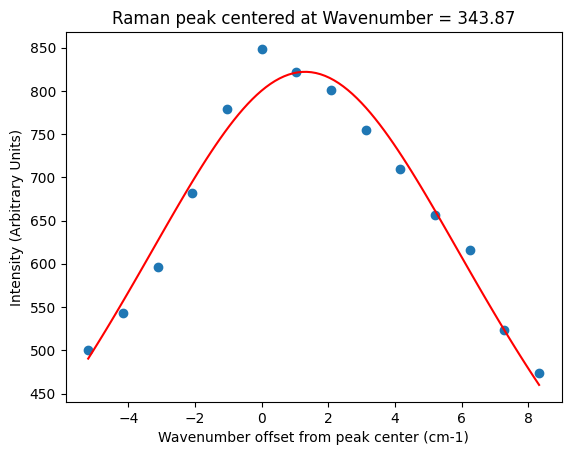

In [ ]:
Rama2= GetFWHM(wn, intensity,345,5,9)

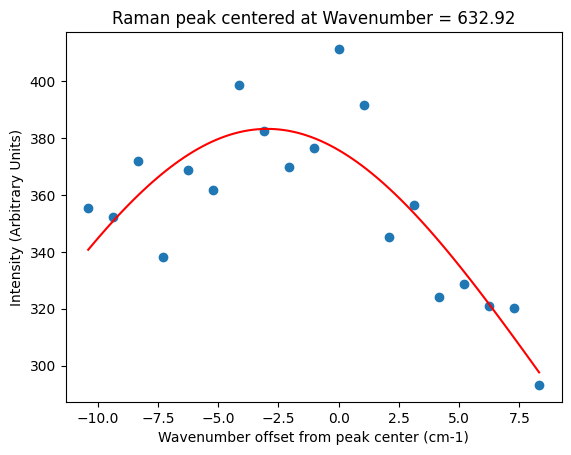

In [ ]:
Rama3= GetFWHM(wn, intensity,630,10,9)

In [ ]:
print('Raman Peak #1')
print('Peak Centered at: ',Rama1[0])
print('Peak FWHM: ',Rama1[1])
print('\n')

print('Raman Peak #2')
print('Peak Centered at: ',Rama2[0])
print('Peak FWHM: ',Rama2[1])
print('\n')


print('Raman Peak #3')
print('Peak Centered at: ',Rama3[0])
print('Peak FWHM: ',Rama3[1])

Raman Peak #1
Peak Centered at:  298.12
Peak FWHM:  13.954333923132072


Raman Peak #2
Peak Centered at:  343.87
Peak FWHM:  15.817892313896676


Raman Peak #3
Peak Centered at:  632.92
Peak FWHM:  42.094745517357865
